# DeBERTa-base Prompt PCL Detection (Local)
Local notebook adapted from the RoBERTa prompt approach with key changes inspired by the PALI-NLP and BEIKE NLP papers:
- **Model**: `microsoft/deberta-base` (DeBERTa-base)
- **Prompt-based cloze classification** with `[MASK]` and multi-word verbalizer
- **RecAdam optimizer** (Chen et al., 2020) to prevent catastrophic forgetting
- **Binary Cross-Entropy loss** instead of NLL loss
- Hard oversampling (8x positives)
- Custom trainer save for tied MLM weights

Additionally, this version concatenates `keyword` and `country` into the prompted input text,
and is compatible with both Kaggle and local training environments.

In [1]:
!pip install contractions python-dotenv huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.3 MB/s eta 0:00:00


In [2]:
import os
import re
import random
import inspect

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')



Using device: cuda


In [3]:
# ============================================================
# Auth: support both Kaggle secrets and local .env
# ============================================================
KAGGLE = True

if KAGGLE:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret('HF_TOKEN')
    if hf_token:
        login(token=hf_token)
        print('HF token loaded from Kaggle secrets and login completed.')
else:
    load_dotenv()
    hf_token = os.getenv('HF_TOKEN')
    if hf_token:
        login(token=hf_token)
        print('HF token loaded from .env and login completed.')
    else:
        print('HF_TOKEN not found in .env; proceeding without explicit login.')

HF token loaded from Kaggle secrets and login completed.


In [4]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME = 'microsoft/deberta-base'
RUN_NAME = 'checkpoints/deberta_base'
MAX_LENGTH = 256

VERBALIZER = {
    0: ['no', 'false', 'never', 'neither'],
    1: ['yes', 'okay', 'true', 'surely'],
}

# Prompt template: keyword + country are prepended separately in model_text
PROMPT_TEMPLATE = '{text} Is it patronizing or condescending? {mask}'

# Paths — auto-detect Kaggle vs local
if KAGGLE and os.path.exists('/kaggle/input'):
    DATA_ROOT = '/kaggle/input/datasets/wowthecoder/patronizing-and-condescending-language-detection'
    OUTPUT_DIR = '/kaggle/working/checkpoints/deberta_base_prompt'
    LOG_DIR = '/kaggle/working/logs'
else:
    DATA_ROOT = '.'
    OUTPUT_DIR = 'checkpoints/deberta_base_prompt'
    LOG_DIR = 'logs'

TSV_PATH = os.path.join(DATA_ROOT, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
TEST_PATH = os.path.join(DATA_ROOT, 'test', 'task4_test.tsv')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# RecAdam hyperparameters (from official repo defaults)
RECADAM_ANNEAL_FUN = 'sigmoid'  # sigmoid annealing
RECADAM_ANNEAL_K = 0.1
RECADAM_ANNEAL_T0 = 1000
RECADAM_ANNEAL_W = 1.0
RECADAM_PRETRAIN_COF = 5000.0

print(f'MODEL_NAME  : {MODEL_NAME}')
print(f'DATA_ROOT   : {DATA_ROOT}')
print(f'OUTPUT_DIR  : {OUTPUT_DIR}')

MODEL_NAME  : microsoft/deberta-base
DATA_ROOT   : /kaggle/input/datasets/wowthecoder/patronizing-and-condescending-language-detection
OUTPUT_DIR  : /kaggle/working/checkpoints/deberta_base_prompt


In [5]:
def load_task1(train_path: str) -> pd.DataFrame:
    """
    Load Task 1 data and convert original labels to binary:
      0/1 -> 0 (No-PCL)
      2/3/4 -> 1 (PCL)
    """
    rows = []
    with open(train_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue

            par_id = parts[0]
            art_id = parts[1]
            keyword = parts[2]
            country = parts[3]
            text = parts[4]
            orig_label = parts[-1]
            label = 0 if orig_label in {'0', '1'} else 1

            rows.append(
                {
                    'par_id': str(par_id),
                    'art_id': art_id,
                    'keyword': keyword,
                    'country': country,
                    'text': text,
                    'label': label,
                    'orig_label': orig_label,
                }
            )

    return pd.DataFrame(
        rows,
        columns=['par_id', 'art_id', 'keyword', 'country', 'text', 'label', 'orig_label'],
    )


In [6]:
# ============================================================
# Load + preprocess data (local module)
# ============================================================
def preprocess_text(text: str) -> str:
    text = str(text)
    text = contractions.fix(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = load_task1(TSV_PATH)
df['clean_text'] = df['text'].apply(preprocess_text)


# DeBERTa uses [SEP] as separator (tokenizer.sep_token)
# We'll use a generic separator here; the tokenizer handles special tokens
df['model_text'] = (
    df['keyword'].str.strip()
    + ' [SEP] '
    + df['country'].str.strip()
    + ' [SEP] '
    + df['clean_text'].str.strip()
)

print(f'Loaded dataset: {len(df):,} samples')
print(df['label'].value_counts().sort_index().rename({0: 'No-PCL', 1: 'PCL'}))
assert set(df['label'].unique()).issubset({0, 1})

Loaded dataset: 10,469 samples
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [7]:
# ============================================================
# Official Train/Dev split + hard oversampling (8x positives)
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df = pd.read_csv(DEV_IDS_PATH, dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids = set(dev_ids_df['par_id'].astype(str))

train_df = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)
dev_df = df[df['par_id'].isin(dev_par_ids)].copy().reset_index(drop=True)

leftover_df = df[~df['par_id'].isin(train_par_ids | dev_par_ids)].copy().reset_index(drop=True)
if len(leftover_df) > 0:
    train_df = pd.concat([train_df, leftover_df], ignore_index=True)
    print(f'Appended {len(leftover_df):,} unassigned samples to training set.')


def describe_split(name: str, frame: pd.DataFrame):
    n = len(frame)
    n_pcl = int((frame['label'] == 1).sum())
    n_no_pcl = int((frame['label'] == 0).sum())
    ratio = f'1:{(n_no_pcl / n_pcl):.1f}' if n_pcl > 0 else 'undefined'
    print(f'{name:<16} -> total={n:,} | PCL={n_pcl:,} | No-PCL={n_no_pcl:,} | ratio={ratio}')


describe_split('Train (before OS)', train_df)
describe_split('Dev', dev_df)

replicated_pcls = pd.concat([train_df[train_df['label'] == 1]] * 8, ignore_index=True)
train_df = pd.concat([train_df, replicated_pcls], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

describe_split('Train (after OS)', train_df)


Train (before OS) -> total=8,375 | PCL=794 | No-PCL=7,581 | ratio=1:9.5
Dev              -> total=2,094 | PCL=199 | No-PCL=1,895 | ratio=1:9.5
Train (after OS) -> total=14,727 | PCL=7,146 | No-PCL=7,581 | ratio=1:1.1


In [8]:
# ============================================================
# Tokenization with prompt wrapping + Hugging Face Datasets
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MASK_TOKEN = tokenizer.mask_token
MASK_TOKEN_ID = tokenizer.mask_token_id
print(f'Mask token: {MASK_TOKEN!r}  (id={MASK_TOKEN_ID})')
print(f'Sep token:  {tokenizer.sep_token!r}')


def resolve_verbalizer_ids(tokenizer, verbalizer):
    class_ids = {}
    for label_idx in sorted(verbalizer.keys()):
        ids = []
        for word in verbalizer[label_idx]:
            # DeBERTa uses sentencepiece; try with leading space
            tokens = tokenizer.encode(' ' + word, add_special_tokens=False)
            tok_id = tokens[0]
            n = len(tokens)
            tag = 'single' if n == 1 else f'multi({n})'
            print(f'  Class {label_idx} -> "{word}" -> id {tok_id}  [{tag}]')
            ids.append(tok_id)
        class_ids[label_idx] = ids
    return class_ids


print('\nVerbalizer token IDs:')
VERBALIZER_IDS = resolve_verbalizer_ids(tokenizer, VERBALIZER)
print(f'Resolved: {VERBALIZER_IDS}')


def build_prompt(text, mask_token):
    return PROMPT_TEMPLATE.format(text=text, mask=mask_token)


_demo = build_prompt('homeless [SEP] gb [SEP] These poor children really need our help', MASK_TOKEN)
print(f'\nExample prompt:\n{_demo}')
print(f'Tokens: {len(tokenizer(_demo)["input_ids"])}')


def add_prompt_column(frame):
    frame = frame.copy()
    frame['prompted_text'] = frame['model_text'].apply(lambda t: build_prompt(t, MASK_TOKEN))
    return frame


train_prompted = add_prompt_column(train_df)
dev_prompted = add_prompt_column(dev_df)

train_hf = Dataset.from_pandas(
    train_prompted[['prompted_text', 'label']].rename(columns={'prompted_text': 'text'}),
    preserve_index=False,
)
dev_hf = Dataset.from_pandas(
    dev_prompted[['prompted_text', 'label']].rename(columns={'prompted_text': 'text'}),
    preserve_index=False,
)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


train_ds = train_hf.map(tokenize, batched=True, remove_columns=['text'])
dev_ds = dev_hf.map(tokenize, batched=True, remove_columns=['text'])

train_ds = train_ds.rename_column('label', 'labels')
dev_ds = dev_ds.rename_column('label', 'labels')

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
dev_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f'\nTrain: {train_ds}')
print(f'Dev:   {dev_ds}')

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Mask token: '[MASK]'  (id=50264)
Sep token:  '[SEP]'

Verbalizer token IDs:
  Class 0 -> "no" -> id 117  [single]
  Class 0 -> "false" -> id 3950  [single]
  Class 0 -> "never" -> id 393  [single]
  Class 0 -> "neither" -> id 5063  [single]
  Class 1 -> "yes" -> id 4420  [single]
  Class 1 -> "okay" -> id 8578  [single]
  Class 1 -> "true" -> id 1528  [single]
  Class 1 -> "surely" -> id 8349  [single]
Resolved: {0: [117, 3950, 393, 5063], 1: [4420, 8578, 1528, 8349]}

Example prompt:
homeless [SEP] gb [SEP] These poor children really need our help Is it patronizing or condescending? [MASK]
Tokens: 27


Map:   0%|          | 0/14727 [00:00<?, ? examples/s]

Map:   0%|          | 0/2094 [00:00<?, ? examples/s]


Train: Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14727
})
Dev:   Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2094
})


In [9]:
# ============================================================
# Metrics (handles log-prob outputs from prompt model)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
    }


In [10]:
# ============================================================
# RecAdam Optimizer
# Adapted from the official implementation:
#   https://github.com/Sanyuan-Chen/RecAdam/blob/master/RecAdam.py
# Paper: "Recall and Learn: Fine-tuning Deep Pretrained Language
#         Models with Less Forgetting" (EMNLP 2020)
# ============================================================
import math
from torch.optim import Optimizer


def anneal_function(function, step, k, t0, weight):
    """Compute annealing coefficient for RecAdam."""
    if function == 'sigmoid':
        return float(1 / (1 + math.exp(-k * (step - t0)))) * weight
    elif function == 'linear':
        return min(1, step / t0) * weight
    elif function == 'constant':
        return weight
    else:
        raise ValueError(f'Unknown anneal function: {function}')


class RecAdam(Optimizer):
    """
    RecAdam: Adam + recall term that penalises deviation from pretrained weights.
    Uses sigmoid annealing to transition from recall-dominated to task-dominated.
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-6,
                 weight_decay=0.0, correct_bias=True,
                 anneal_fun='sigmoid', anneal_k=0.1, anneal_t0=1000,
                 anneal_w=1.0, pretrain_cof=5000.0, pretrain_params=None):
        defaults = dict(
            lr=lr, betas=betas, eps=eps, weight_decay=weight_decay,
            correct_bias=correct_bias,
            anneal_fun=anneal_fun, anneal_k=anneal_k, anneal_t0=anneal_t0,
            anneal_w=anneal_w, pretrain_cof=pretrain_cof,
        )
        super().__init__(params, defaults)
        self.pretrain_params = pretrain_params or {}

    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            for p_name, p in zip(group.get('names', [None] * len(group['params'])),
                                 group['params']):
                if p.grad is None:
                    continue

                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError('RecAdam does not support sparse gradients')

                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)
                    state['exp_avg_sq'] = torch.zeros_like(p.data)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1, beta2 = group['betas']
                state['step'] += 1

                # Decay the first and second moment running average coefficient
                exp_avg.mul_(beta1).add_(grad, alpha=1.0 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1.0 - beta2)
                denom = exp_avg_sq.sqrt().add_(group['eps'])

                step_size = group['lr']
                if group['correct_bias']:
                    bias_correction1 = 1.0 - beta1 ** state['step']
                    bias_correction2 = 1.0 - beta2 ** state['step']
                    step_size = step_size * math.sqrt(bias_correction2) / bias_correction1

                # Compute the RecAdam recall term
                if p_name and p_name in self.pretrain_params:
                    anneal_coef = anneal_function(
                        group['anneal_fun'], state['step'],
                        group['anneal_k'], group['anneal_t0'], group['anneal_w'],
                    )
                    # Blend: anneal_coef * Adam_update + (1 - anneal_coef) * recall_to_pretrained
                    pretrain_p = self.pretrain_params[p_name].to(p.device)
                    p.data.add_(
                        # Adam part (scaled by anneal_coef)
                        -step_size * anneal_coef * (exp_avg / denom + group['weight_decay'] * p.data)
                        # Recall part (scaled by 1 - anneal_coef)
                        - group['lr'] * (1 - anneal_coef) * group['pretrain_cof'] * (p.data - pretrain_p)
                    )
                else:
                    # Standard AdamW update for non-pretrained params (e.g. classifier head)
                    p.data.addcdiv_(exp_avg, denom, value=-step_size)
                    if group['weight_decay'] > 0.0:
                        p.data.add_(p.data, alpha=-group['lr'] * group['weight_decay'])

        return loss


print('RecAdam optimizer defined (from official Sanyuan-Chen/RecAdam repo).')

RecAdam optimizer defined (from official Sanyuan-Chen/RecAdam repo).


In [11]:
# ============================================================
# Model: Prompt-based DeBERTa with multi-word verbalizer + BCE loss
# ============================================================
class PromptMLMClassifier(nn.Module):
    def __init__(self, model_name, verbalizer_ids, mask_token_id):
        super().__init__()
        self.mlm = AutoModelForMaskedLM.from_pretrained(model_name)
        self.verbalizer_ids = verbalizer_ids
        self.mask_token_id = mask_token_id
        self.num_classes = len(verbalizer_ids)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.mlm(input_ids=input_ids, attention_mask=attention_mask)
        vocab_logits = outputs.logits

        mask_flags = (input_ids == self.mask_token_id)
        mask_pos = mask_flags.long().argmax(dim=-1)

        batch_size = input_ids.shape[0]
        batch_idx = torch.arange(batch_size, device=input_ids.device)
        mask_logits = vocab_logits[batch_idx, mask_pos, :]

        # Get mean logits for positive and negative verbalizer words
        pos_ids = torch.tensor(self.verbalizer_ids[1], device=input_ids.device, dtype=torch.long)
        neg_ids = torch.tensor(self.verbalizer_ids[0], device=input_ids.device, dtype=torch.long)
        pos_logits = mask_logits[:, pos_ids].mean(dim=-1)  # (batch,)
        neg_logits = mask_logits[:, neg_ids].mean(dim=-1)  # (batch,)

        # Stack into 2-class logits for compatibility with compute_metrics
        class_logits = torch.stack([neg_logits, pos_logits], dim=-1)  # (batch, 2)
        class_probs = torch.softmax(class_logits, dim=-1)

        loss = None
        if labels is not None:
            # Binary Cross-Entropy on positive-class probability
            pos_prob = class_probs[:, 1]
            loss = F.binary_cross_entropy(pos_prob, labels.float())

        return SequenceClassifierOutput(loss=loss, logits=class_logits)


model = PromptMLMClassifier(
    model_name=MODEL_NAME,
    verbalizer_ids=VERBALIZER_IDS,
    mask_token_id=MASK_TOKEN_ID,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

training_args = TrainingArguments(
    RUN_NAME,
    num_train_epochs=2,
    save_total_limit=2,
    learning_rate=1e-5,
    eval_strategy='epoch',
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=1,
    warmup_steps=2000,
    lr_scheduler_type='cosine',
    weight_decay=0.01,
    report_to='none',
    seed=SEED,
)


class PromptTrainer(Trainer):
    """Custom Trainer that uses RecAdam and handles tied-weight saving."""

    def create_optimizer(self):
        """Override to use RecAdam instead of AdamW."""
        if self.optimizer is not None:
            return self.optimizer

        # Store pretrained params for recall term
        pretrain_params = {
            name: param.detach().clone()
            for name, param in self.model.named_parameters()
        }

        # Build param groups with names (required by RecAdam)
        decay_params = []
        decay_names = []
        no_decay_params = []
        no_decay_names = []

        for name, param in self.model.named_parameters():
            if not param.requires_grad:
                continue
            if 'bias' in name or 'LayerNorm' in name or 'layernorm' in name:
                no_decay_params.append(param)
                no_decay_names.append(name)
            else:
                decay_params.append(param)
                decay_names.append(name)

        optimizer_grouped_parameters = [
            {
                'params': decay_params,
                'names': decay_names,
                'weight_decay': self.args.weight_decay,
            },
            {
                'params': no_decay_params,
                'names': no_decay_names,
                'weight_decay': 0.0,
            },
        ]

        self.optimizer = RecAdam(
            optimizer_grouped_parameters,
            lr=self.args.learning_rate,
            betas=(0.9, 0.999),
            eps=1e-6,
            correct_bias=True,
            anneal_fun=RECADAM_ANNEAL_FUN,
            anneal_k=RECADAM_ANNEAL_K,
            anneal_t0=RECADAM_ANNEAL_T0,
            anneal_w=RECADAM_ANNEAL_W,
            pretrain_cof=RECADAM_PRETRAIN_COF,
            pretrain_params=pretrain_params,
        )

        print(f'RecAdam optimizer created with anneal_fun={RECADAM_ANNEAL_FUN}, '
              f'anneal_k={RECADAM_ANNEAL_K}, anneal_t0={RECADAM_ANNEAL_T0}, '
              f'pretrain_cof={RECADAM_PRETRAIN_COF}')
        return self.optimizer

    def _save(self, output_dir=None, state_dict=None):
        # Save inner MLM model to avoid tied-weight safetensors errors.
        output_dir = output_dir if output_dir is not None else self.args.output_dir
        os.makedirs(output_dir, exist_ok=True)

        unwrapped = self.model
        if hasattr(unwrapped, 'module'):
            unwrapped = unwrapped.module

        unwrapped.mlm.save_pretrained(output_dir, safe_serialization=False)

        if self.processing_class is not None:
            self.processing_class.save_pretrained(output_dir)

        torch.save(self.args, os.path.join(output_dir, 'training_args.bin'))

        import json as _json
        vc = {
            'verbalizer': {str(k): v for k, v in VERBALIZER.items()},
            'verbalizer_ids': {str(k): v for k, v in VERBALIZER_IDS.items()},
            'prompt_template': PROMPT_TEMPLATE,
            'mask_token_id': unwrapped.mask_token_id,
        }
        with open(os.path.join(output_dir, 'verbalizer_config.json'), 'w') as f:
            _json.dump(vc, f, indent=2)


trainer = PromptTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Trainer configured with RecAdam + BCE loss.')

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
DebertaForMaskedLM LOAD REPORT from: microsoft/deberta-base
Key                                        | Status     | 
-------------------------------------------+------------+-
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
cls.predictions.transform.dense.weight     | MISSING    | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.decoder.bias               | MISSING    | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.bias                      

Trainable parameters: 139,244,121
Trainer configured with RecAdam + BCE loss.


In [12]:
train_result = trainer.train()
train_result


RecAdam optimizer created with anneal_fun=sigmoid, anneal_k=0.1, anneal_t0=1000, pretrain_cof=5000.0


model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,F1 Macro,Precision Macro,Recall Macro
1,0.309676,0.449864,0.747868,0.711977,0.814178
2,0.074497,0.548720,0.777282,0.787531,0.767963


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7364, training_loss=0.34147910823127875, metrics={'train_runtime': 1134.8057, 'train_samples_per_second': 25.955, 'train_steps_per_second': 6.489, 'total_flos': 0.0, 'train_loss': 0.34147910823127875, 'epoch': 2.0})

In [13]:
eval_metrics = trainer.evaluate()
print('Evaluation metrics:')
for k, v in eval_metrics.items():
    if isinstance(v, (int, float)):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')


Evaluation metrics:
  eval_loss: 0.5487
  eval_f1_macro: 0.7773
  eval_precision_macro: 0.7875
  eval_recall_macro: 0.7680
  eval_runtime: 17.9343
  eval_samples_per_second: 116.7590
  eval_steps_per_second: 29.2180
  epoch: 2.0000


              precision    recall  f1-score   support

      No-PCL     0.9555    0.9631    0.9593      1895
         PCL     0.6196    0.5729    0.5953       199

    accuracy                         0.9260      2094
   macro avg     0.7875    0.7680    0.7773      2094
weighted avg     0.9236    0.9260    0.9247      2094



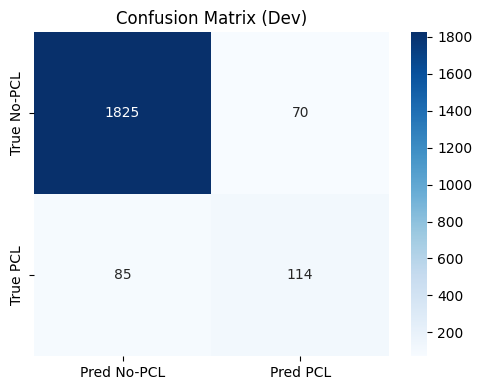

In [14]:
# ============================================================
# Detailed evaluation report
# ============================================================
pred_output = trainer.predict(dev_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print(classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred No-PCL', 'Pred PCL'],
    yticklabels=['True No-PCL', 'True PCL'],
)
plt.title('Confusion Matrix (Dev)')
plt.tight_layout()
plt.show()


In [15]:
# ============================================================
# Save best model
# ============================================================
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, 'best')
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

model.mlm.save_pretrained(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

import json
verbalizer_config = {
    'verbalizer': {str(k): v for k, v in VERBALIZER.items()},
    'verbalizer_ids': {str(k): v for k, v in VERBALIZER_IDS.items()},
    'prompt_template': PROMPT_TEMPLATE,
    'mask_token_id': MASK_TOKEN_ID,
}
with open(os.path.join(BEST_MODEL_DIR, 'verbalizer_config.json'), 'w') as f:
    json.dump(verbalizer_config, f, indent=2)

print(f'Saved best model, tokenizer, and verbalizer config to: {BEST_MODEL_DIR}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best model, tokenizer, and verbalizer config to: /kaggle/working/checkpoints/deberta_base_prompt/best
